In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:80% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:10pt;}
div.output {font-size:10pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:10pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:10pt;padding:5px;}
table.dataframe{font-size:14px;}
</style>
"""))

<font size="6" color="green">ch11. 데이터프레임과 시리즈(Pandas)</font>
- pip install pandas (아나콘다 프롬프트)

# 1절. 판다스 패키지
- 데이터 분석을 위해 반드시 알아야할 패키지. 넘파이를 기반으로 하며, 다른 많은 라이브러리와 잘 통합되도록 설계
- 1차원 구조를 갖는 시리즈 / 2차원 구조를 갖는 데이터 프레임을 제공
- 판다스 장점 : 데이터 프레임 생성, 파일 i/o, 레이블링, 부분 데이터 추출, 크기변경(행이나 열 삽입 삭제)
              데이퍼 분할, 병합, 데이터 정렬, 결측치 처리, 피벗과 언피벗 등이 용이
- https://pandas.pydata.org/docs/ (API reference)

In [2]:
import pandas as pd
pd.__version__

'1.5.3'

In [10]:
data = pd.read_json('Data/ch09_member1.json')
# , encoding = 'utf-8' 판다스 read함수의 기본 encoding은 utf-8
display(data)
print(type(data))

,name,age,email,address,job
0,홍길동,20,h@h.com,서울시 관악구,-
1,신길동,40,s@h.com,서울시 영등포구,팀장
2,김길동,30,k@h.com,서울시 동작구,-


<class 'pandas.core.frame.DataFrame'>


In [13]:
member4 = pd.read_csv('Data/ch09_member4.csv') # 해더가 있는 csv
member4

,name,age,email,address
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [22]:
member1 = pd.read_csv('Data/ch09_member1.csv', 
                     header=None
                     names=['이름', '나이', '메일', '주소'])
member1

,0,1,2,3
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [23]:
pd.read_hdf('Data/ch09_iris.h5', key='iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 2절. 데이터 프레임 만들기

## 2.1 딕셔너리를 이용해서 데이터 프레임 만들기



In [25]:
d = {'kor':[100,90], 'mat':[95, 90]}
df = pd.DataFrame(data=d)
df

,kor,mat
0,100,95
1,90,90


In [26]:
df.to_dict() # 데이터프레임을 딕셔너리로 만듦

{'kor': {0: 100, 1: 90}, 'mat': {0: 95, 1: 90}}

In [27]:
df.to_numpy() # 데이터프레임을 넘파이배열로 만듦

array([[100,  95],
       [ 90,  90]], dtype=int64)

In [29]:
d = [{'kor': 100, 'mat' : 95},
    {'kor': 90, 'mat' : 99}]
df = pd.DataFrame(d) # 데이터프레임의 열은 동일 자료형
df

,kor,mat
0,100,95
1,90,99


In [30]:
df.dtypes # 데이터프레임의 열별 타입

kor    int64
mat    int64
dtype: object

In [31]:
df.info() # ★ 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   kor     2 non-null      int64
 1   mat     2 non-null      int64
dtypes: int64(2)
memory usage: 160.0 bytes


In [40]:
import numpy as np
df['kor'] = df['kor'].astype(np.float64) # 데이터프레임의 열 타입 변경
df

,kor,mat
0,100.0,95
1,90.0,99


In [41]:
d = [{'kor': 100, 'mat':100},
    {'kor': 90, 'mat': 99},
    {'kor': 80, 'eng': 85}]
df = pd.DataFrame(data = d)
df

,kor,mat,eng
0,100,100.0,NaN
1,90,99.0,NaN
2,80,NaN,85.0


In [42]:
type(np.nan) # 결측치의 타임 : float

float

In [ ]:
# 결측치는 int로 형변환이 불가
df['mat'].astype(np.int32)

## 2.2 리스트를 이용해서 데이터프레임 만들기

In [43]:
kor = [100, 90, 80, 70, 60]
mat = [90, 91, 81, 71, 61]
df = pd.DataFrame({'kor':kor, 'mat': mat})
df

,kor,mat
0,100,90
1,90,91
2,80,81
3,70,71
4,60,61


In [49]:
pd.DataFrame(np.c_[kor, mat], columns=['kor', 'mat'])

,kor,mat
0,100,90
1,90,91
2,80,81
3,70,71
4,60,61


In [52]:
l = [[100, 90], [70, 80]]
pd.DataFrame(l, columns = ['국어', '수학'])

,국어,수학
0,100,90
1,70,80


- data.go.kr에서 "상가상권 정보" 다운로드 / "민간 아파트 분양가격" 다운로드

In [67]:
%ls "C:\ai\Downloads\shareData\상가정보\"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 1828-3575

 C:\ai\Downloads\shareData\상가정보 디렉터리

2026-07-14  오후 05:39    <DIR>          .
2026-07-14  오후 05:39    <DIR>          ..
2025-11-03  오전 12:45             1,011 [필독]파일열람방법.txt
2026-04-27  오전 11:10        61,321,696 소상공인시장진흥공단_상가(상권)정보_강원_202603.csv
2026-04-27  오전 11:10       367,852,181 소상공인시장진흥공단_상가(상권)정보_경기_202603.csv
2026-04-27  오전 11:10        92,474,293 소상공인시장진흥공단_상가(상권)정보_경남_202603.csv
2026-04-27  오전 11:10        76,309,810 소상공인시장진흥공단_상가(상권)정보_경북_202603.csv
2026-04-27  오전 11:10        40,031,721 소상공인시장진흥공단_상가(상권)정보_광주_202603.csv
2026-04-27  오전 11:10        61,825,564 소상공인시장진흥공단_상가(상권)정보_대구_202603.csv
2026-04-27  오전 11:10        41,866,930 소상공인시장진흥공단_상가(상권)정보_대전_202603.csv
2026-04-27  오전 11:10        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-04-27  오전 11:10       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-04-27  오전 11:10         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
2026-04-27  오전 11:10        28,285,232 소상공인시장진흥공단

In [70]:
df = pd.read_csv(r'C:\ai\Downloads\shareData\상가정보\소상공인시장진흥공단_상가(상권)정보_세종_202603.csv',
               # encoding = 'utf-8', sep=','
                nrows=30, # 처음 30행만 가져오기
                low_memory=False, # 데이터 용량이 클 경우 기입
                )
df.shape # 30행 39열

(30, 39)

In [71]:
df.head(1) # 상위 1행

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220813963449,레인카페,NaN,I2,음식,I212,비알코올,I21201,카페,I56229,...,4473025021101010001038753,NaN,세종특별자치시 세종특별자치시 조치원읍 조치원8길 16,339883.0,30027,NaN,지,NaN,127.300453,36.600906


In [77]:
# 판다스 display옵션
pd.options.display.max_columns = 39 # 39열까지 display
pd.options.display.max_rows = 40 # 30행까지 display

In [79]:
df.head(2).T

,0,1
상가업소번호,MA010120220813963449,MA010120220805872513
상호명,레인카페,수와마을
지점명,NaN,NaN
상권업종대분류코드,I2,I2
상권업종대분류명,음식,음식
상권업종중분류코드,I212,I201
상권업종중분류명,비알코올,한식
상권업종소분류코드,I21201,I20101
상권업종소분류명,카페,백반/한정식
표준산업분류코드,I56229,I56111


## 2.3 read_csv

### (1) csv 파일 불러오기(기본값)

In [2]:
import pandas as pd
member = pd.read_csv('Data/ch11_member.csv')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01


In [3]:
member.info() # ★ 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      int64 
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: int64(1), object(4)
memory usage: 368.0+ bytes


#### # 문자형으로 변환

In [9]:
member['Age'] = member['Age'].astype('str')
member['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6 entries, 0 to 5
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
6 non-null      object
dtypes: object(1)
memory usage: 176.0+ bytes


#### # 숫자형으로 변환

In [17]:
import numpy as np
member['Age'].astype('int16')
member['Age'].astype(np.int16)
member['Age'] = pd.to_numeric(member['Age'], 
                  downcast='integer', # 빼면 inr32나 float64로 자동 변환
                  errors='coerce')  # 숫자로 바꿀 수 없는 데이터는 결측치로 변환 ex) 3,000
member.dtypes

Name       object
Age          int8
Email      object
Address    object
Birth      object
dtype: object

#### # 문자로 읽어들인 Birth를 datetime형으로

In [22]:
# member.loc[0, 'Birth'] # 1999-01-01, 01-01-1999, 19990101
member['Birth'].astype('datetime64[ns]')
member['Birth'] = member['Birth'].astype('datetime64[ns]')
member.astype({'Birth':'datetime64[ns]', 'Age':'int32'})
member = member.astype({'Birth':'datetime64[ns]', 'Age':'int32'})
# 01-01-1999, 19990101
member['Birth'] = pd.to_datetime(member['Birth'],
              # format='%Y-%m-%d %H:%M:%S'
              )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      6 non-null      int32         
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int32(1), object(3)
memory usage: 344.0+ bytes


In [28]:
member['year'] = member.Birth.dt.year
member['month'] = member.Birth.dt.month
member['day'] = member.Birth.dt.day

member

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1


In [29]:
current_date = pd.to_datetime('2026-07-15')
member['일수'] = (current_date - member.Birth).dt.days
member

,Name,Age,Email,Address,Birth,year,month,day,일수
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1,10057
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1,9723
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1,9753
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1,9937
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30,10028
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1,9692


### (2) 특정행을 제외하고 cp949 encoding 파일 읽어오기

In [31]:
member = pd.read_csv('data/ch11_membercp949.csv',
                    encoding = 'cp949',
                    skiprows=[1, 6]) # 1, 6행을 제외하고 읽기
member

,Name,Age,Email,Address,Birth
0,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


### (3) sep = '|', 주석(#) 제외, 상위 몇행만, datetime형 필드지정

In [33]:
member_df = pd.read_csv('Data/ch11_membersep.csv',
                       sep='|',               # |기주으로 데이터를 분리해서 읽기
                       comment='#',           # #이 있는 행은 제외하고 읽기
                       nrows=3,               # 상위 3행만 읽기
                       parse_dates=['Birth']) # datetime형으로 읽어올 필드 지정
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [34]:
member_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     3 non-null      object        
 1   Age      3 non-null      int64         
 2   Email    3 non-null      object        
 3   Address  3 non-null      object        
 4   Birth    3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 248.0+ bytes


In [35]:
member_df = pd.read_csv('Data/ch11_membertab.csv',
                       sep='\t',
                       comment='#',
                       parse_dates=['Birth'])
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 2.4 패키지에서 가져오기 : iris데이터
- iris가져오기 방법1 : sklearn(머신러닝 패키지)
- iris가져오기 방법2 : statsmodels (R 데이터)
- iris가져오기 방법3 : seaborn(시각화 패키지)

### 1. iris 방법 1 : sklearn
- sklearn.datasets 모듈 데이터(iris)를 데이터프레임으로 변환

In [37]:
from sklearn import datasets
# import sklearn.datasets as datasets : 머신러닝을 공부하기 위한 학습용 데이터셋을 제공
# sklearn 패키지의 데이터셋 : 독립변수(입력변수)와 종속변수(타겟변수)가 분리된 딕셔너리 형태 제공
iris = datasets.load_iris() # 딕셔너리형태
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [38]:
print(iris.DESCR) # iris 데이터셋에 대한 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [40]:
iris.data # 독립변수
iris['data'][:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [43]:
# pd.DataFrame(iris.data)
iris.feature_names # 독립변수의 열이름
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [54]:
# 데이터프레임에서 독립변수 열이름
[col[:-5].replace(' ', '_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [53]:
[col[:12].strip().replace(' ', '_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

#### # 종속변수(타겟변수)

In [55]:
iris.target
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [57]:
iris.target_names
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [58]:
# 데이터프레임에 가장 오른쪽 열 (타겟변수-species)
iris.target_names[iris.target]
iris['target_names'][iris['target']]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [69]:
# 독립변수 : [col[:-5].replace(' ', '_') for col in iris.feature_names]
data = iris.data
print(data[::50])
# 종속변수 : species
target = iris.target_names[iris.target].reshape(-1, 1)
print(target[::50])

[[5.1 3.5 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]]
[['setosa']
 ['versicolor']
 ['virginica']]


In [70]:
print('독립변수의 차원 :', data.shape)
print('종속변수의 차원 :', target.shape)

독립변수의 차원 : (150, 4)
종속변수의 차원 : (150, 1)


#### ⓐ 독립변수, 종속변수를 stack한 후, 데이터프레임으로 생성

In [74]:
import numpy as np
df = pd.DataFrame(np.hstack( (data, target)),
                 columns=[col[:-5].replace(' ', '_') for col in iris.feature_names] + ['species'])
df.head(3) # 상위 5행만

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [72]:
df['petal_width']
df.petal_width[:3]

0    0.2
1    0.2
2    0.2
Name: petal_width, dtype: object

In [77]:
df['petal width (cm)'][:3]
#df.petal width (cm) # 에러남

0    0.2
1    0.2
2    0.2
Name: petal width (cm), dtype: object

#### ⓑ 독립변수, 종속변수를 따로  데이터프레임으로 생성한 후 두 데이터프레임을 연결
- X : 독립변수 데이터프레임
- y : 종속변수 데이터프레임

In [79]:
# x
X = pd.DataFrame(data, columns=[col[:-5].replace(' ', '-')for col in iris.feature_names])
X.head(1)

,sepal-length,sepal-width,petal-length,petal-width
0,5.1,3.5,1.4,0.2


In [80]:
# y
y = pd.DataFrame(target, columns=['species'])
y.tail() # 하위 5줄을 출력해라

,species
145,virginica
146,virginica
147,virginica
148,virginica
149,virginica


In [82]:
print(X.index) # index : 행이름
print(y.index)

RangeIndex(start=0, stop=150, step=1)
RangeIndex(start=0, stop=150, step=1)


In [84]:
# 두 데이터프레임을 연결 (row로 연결)
iris_df = pd.concat([X, y], axis=1)

iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 2. iris 방법 2 : statsmodles

In [86]:
from statsmodels.api import datasets
iris_dataset = datasets.get_rdataset('iris',
                                    package='datasets',
                                    cache=True) # 데이터를 pc에 저장(~/statsmodels)
iris_dataset

<class 'statsmodels.datasets.utils.Dataset'>

In [88]:
iris = iris_dataset.data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [90]:
iris['Sepal.Length'][:3]
# iris.Sepal.Length _사용불가

0    5.1
1    4.9
2    4.7
Name: Sepal.Length, dtype: float64

In [93]:
# 열 이름 수정
[col.replace('.','_').lower() for col in iris.columns]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [94]:
iris.columns = [col.replace('.','_').lower() for col in iris.columns]
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


### 3. iris방법 3 : seabron

In [96]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [100]:
# 데이터프레임을 파일로 출력
iris.to_csv('Data/ch11_iris.csv', # 4.5kb
#            sep=',',
#            encoding='utf-8',
           index=False) # 행이름이 생략되서 파일 출력해

In [101]:
iris.to_csv('Data/ch11_iris.gz', # 885B
           index=False,
           compression='infer') # 파일 확장자 (.zip, .gz, .bz2등)를 보고 자동으로 앞축형식을 추론해서 압축

In [102]:
load_iris = pd.read_csv('Data/ch11_iris.csv')
load_iris.sample(3) # 임의로 세개 가져오기

,sepal_length,sepal_width,petal_length,petal_width,species
36,5.5,3.5,1.3,0.2,setosa
142,5.8,2.7,5.1,1.9,virginica
72,6.3,2.5,4.9,1.5,versicolor


In [ ]:
load_iris = pd.read_csv('Data/ch11_iris.gz', compression='infer')
load_iris.sample(3)

# 3절. 이름(열, 행) 지정하기
## 3.1 열 이름 정하기

In [103]:
member = pd.read_csv('Data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [ ]:
member.columns # 열 이름

In [104]:
member.columns =['이름', '나이', '메일', '주소', '생년월일']
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.2 행 이름 지정

In [105]:
member.index

RangeIndex(start=0, stop=5, step=1)

In [106]:
member.index = range(10,15)
member

,이름,나이,메일,주소,생년월일
10,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
11,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
12,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
13,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
14,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [108]:
member.index = ['동', '서', '남', '북', '중']
member

,이름,나이,메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [109]:
member['이름']

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: 이름, dtype: object

In [110]:
member.loc['서']

이름                      홍길서
나이                       30
메일             seo@hong.com
주소                   서울시 중구
생년월일    1999-12-01 00:00:00
Name: 서, dtype: object

In [111]:
member.loc['서', '이름'] # loc [행이름, 열이름]으로 부분 데이테 조회(4절)

'홍길서'

In [112]:
# 이름을 행이름으로 (실행결과가 출력되서 나오면 return될 뿐, member가 안 바뀜)
# member를 이름열을 행이름으로 수정 (1)할당 (2) inplace 매개변수에 True(기본값은 False)

Index(['동', '서', '남', '북', '중'], dtype='object')
None


In [114]:
member.set_index('이름', inplace=True)

In [115]:
member

,나이,메일,주소,생년월일
이름,,,,
홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
홍길서,30,seo@hong.com,서울시 중구,1999-12-01
홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [117]:
print(member.index)
print(member.index.name)
print(member.columns)

Index(['홍길동', '홍길서', '홍길남', '홍길북', '홍길중'], dtype='object', name='이름')
이름
Index(['나이', '메일', '주소', '생년월일'], dtype='object')


In [119]:
# 인덱스를 열에 편입시키기
# member.reset_index(inplace=True)
member = member.reset_index()

In [121]:
member.index = [0, 11, 2, 3, 4]
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
11,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [122]:
# 기존 index를 0부터 새롭게 다시 numbering (비추천 방식)
member.index = range(len(member))
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [125]:
member.index = [ 99, 66, 44, 55, 22]
# 기존 index를 새로운 열에 편입시키지 않고 제거 후 숫자 index를 초기화(추천 방식)
member.reset_index(drop=True, inplace=True)

In [126]:
member

,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.3 레벨 이름 지정하기

In [127]:
print(member.columns)
print(member.columns.name)
display(member)

Index(['이름', '나이', '메일', '주소', '생년월일'], dtype='object')
None


,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [128]:
member.columns.name = '컬럼명'
member

컬럼명,이름,나이,메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [130]:
member.columns = [['기본정보', '기본정보', '기본정보', '추가정보', '추가정보'],
                 ['이름',      '나이',     '메일',   '주소',    '생년월일']]
member.columns.names = ['대분류', '소분류']
member

대분류 기본정보                        추가정보           
소분류   이름  나이             메일       주소       생년월일
0    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
1    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
2    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
3    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
4    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [148]:
member.index = [['좌우', '좌우', '상하', '상하', '상하'],
             ['동', '서','남', '북', '중']]
member.index.names = ['레벨 1', '레벨2']
member

대분류      기본정보                        추가정보           
소분류        이름  나이             메일       주소       생년월일
레벨 1 레벨2                                            
좌우   동    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
     서    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하   남    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
     북    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
     중    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [138]:
member[('기본정보', '이름')]

레벨 1  레벨2
좌우    동      홍길동
      서      홍길서
상하     남     홍길남
      북      홍길북
      중      홍길중
Name: (기본정보, 이름), dtype: object

In [139]:
member.loc['상하']

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨2                                           
 남   홍길남  21  nam@hong.com  서울시 강동구 1999-11-01
북    홍길북  22  buk@hong.com  서울시 관악구 1999-05-01
중    홍길중  23  mid@hong.com   부산시 중구 1999-01-30

In [150]:
member.loc[('상하','남'),('기본정보')]

소분류
이름             홍길남
나이              21
메일    nam@hong.com
Name: (상하, 남), dtype: object

In [151]:
member.xs(key='남', level='레벨2')

대분류  기본정보                       추가정보           
소분류    이름  나이            메일       주소       생년월일
레벨 1                                           
상하    홍길남  21  nam@hong.com  서울시 강동구 1999-11-01

In [142]:
member.loc['좌우', '기본정보']

소분류,이름,나이,메일
레벨2,,,
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com


# 4절 부분 데이터 조회

In [154]:
member = pd.read_csv('Data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.1 열 조회
- df[열이름]
- df[조건]
- df[열이름들]

In [155]:
member['Name']
member.Name

0    홍길동
1    홍길서
2    홍길남
3    홍길북
4    홍길중
Name: Name, dtype: object

In [156]:
member[['Name', 'Age', 'Birth']]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


In [ ]:
# membe[0] : 행이름으로 조회할 경우 loc 사용

## 4.2 loc을 이용한 조회
- df.loc [행이름, 열이름] : 행이름과 열이름으로 조회
    * 행이름과 열이름 자리에 슬라리싱(from:to)는 from부터 to까지 (to포함)
    * 행이름과 열이름 자리에 list가능
    * 열이름 생략할 경우 모든 열 조회

In [160]:
member.loc[0:2] # 0행부터 2행까지
member.loc[0:2,]
member.loc[0:2, :]
member.loc[0:2, ...]
# 모든 열을 다 출력할 경우 생략 가능

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [171]:
member.index = ['동', '서', '남', '북', '중']
member.loc['동':'남']

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [172]:
# 동~남행까지 Name~Email만 조회
member.loc['동':'남', 'Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [173]:
# 동행과 남행만 조회
member.loc[['동', '남']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [174]:
# 모든 행의 Name열
member.loc[:, 'Name'] # 한 열이나 한 행은 결과가 1차원 시리즈
member.loc[..., 'Name']

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: Name, dtype: object

In [175]:
member.loc['동']

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [176]:
type(member.loc['동']), type(member.loc[:, 'Name'])

(pandas.core.series.Series, pandas.core.series.Series)

## 4.3 iloc을 이용한 조회
- df.iloc[행번호, 열번호]
    * 행번호, 열번호 자리에는 list, 슬라이싱 [from:stop:by] : from부터 stop앞까지 by씩
    * 열번호 생략시 모든 열 조회
    *

In [177]:
# 두번째 ~세번째까지 행 (0이 처음)
member.loc['서':'남']
member.iloc[2:4]

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [178]:
member.iloc[0] # 1차원 시리즈

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [179]:
# 0번째 ~2번째행, 1번째~2번째열
member.iloc[0:3, 1:3]

,Age,Email
동,20,hong@hong.com
서,30,seo@hong.com
남,21,nam@hong.com


In [180]:
# 0번째행과 2번째행, 1번째열과 3번째열
member.iloc[[0,2], [1,3]]

,Age,Address
동,20,서울시 강동구
남,21,서울시 강동구


In [182]:
# 짝수번째행(0, 2, 4번째)의 맨 마지막열을 제외하고 조회
member.iloc[::2, :-1]

,Name,Age,Email,Address
동,홍길동,20,hong@hong.com,서울시 강동구
남,홍길남,21,nam@hong.com,서울시 강동구
중,홍길중,23,mid@hong.com,부산시 중구


In [183]:
# 마지막행부터 처음행까지 꺼꾸로 출력
member.iloc[::-1]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


## 4.4 조건으로 조회

In [184]:
member['Age']>=23

동    False
서     True
남    False
북    False
중     True
Name: Age, dtype: bool

In [186]:
member.loc[[False, True, False, False, True]]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [188]:
# 23세 이상의 데이터만 조회 (아래 모두 동일한 결과)
member.loc[member['Age']>=23]
member.loc[member['Age']>=23, :]
member[member['Age']>=23]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [192]:
# 23세 이상의 데이터 중 Name, Age, Email
member.loc[member['Age']>=23, ['Name', 'Email']]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


In [193]:
# 23세 이상이 아닌 데이터(모든 열) : ~ (반대)
member[~(member['Age']>=23)]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [196]:
# 관악구가 포함되어 있는지
address = '서울시 관악구 신림동'
print(address.find('관악구')!=-1)
print(address.find('중구')!=-1)

True
False


In [197]:
# 서울시로 시작되는지
print(address.startswith('서울시'))

True


In [ ]:
# member['Address'].find('중구') # 시리즈에 문자함수를 바로 사용 X 

※ 시리즈에 문자함수를 쓰기 위한 참조(https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling)

In [229]:
# Address가 중구인 데이터
member['Address'].str.find('중구')!=-1

# Address 중구가 포함된 데이터
member[member['Address'].str.contains('중구')!=-1]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [230]:
# Address가 중구이거나 관악구인 데이터
member[member['Address'].str.contains('중구|관악구')]

,Name,Age,Email,Address,Birth
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [231]:
# Address에 중구가 포함된 데이터
member[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1, :]

,Name,Age,Email,Address,Birth
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [232]:
# Address에 중구가 포함된 데이터의 Name, Age, Email
member.loc[member['Address'].str.find('중구')!=-1, 'Name':'Email']
member.loc[member['Address'].str.find('중구')!=-1, ['Name', 'Age', 'Email']]

,Name,Age,Email
1,홍길서,30,seo@hong.com
4,홍길중,23,NaN


In [233]:
# Address가 서울이 아닌 데이터
member[~member['Address'].str.startswith('서울')]

,Name,Age,Email,Address,Birth
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [235]:
# Name이 홍길동이거나 홍길남인 데이터의 모든 열
member[(member['Name']=='홍길동') | (member['Name']=='홍길남')]
member[member['Name'].isin(['홍길동', '홍길서', '홍길남'])]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01


In [236]:
# Name이 홍길동이거나 홍길남인 데이터의 Name, Age, Email
member.loc[member['Name'].isin(['홍길동', '홍길서', '홍길남']),'Name':'Email']
member.loc[member['Name'].isin(['홍길동', '홍길서', '홍길남']),['Name', 'Age', 'Email']]

,Name,Age,Email
0,홍길동,20,hong@hong.com
1,홍길서,30,seo@hong.com
2,홍길남,21,NaN


In [237]:
# 1월생인 데이터
member[member['Birth'].dt.month==1]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [238]:
# 1월생이면서 서울시인 데이터
member.loc[(member.Birth.dt.month==1)&member.Address.str.startswith('서울시')]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [240]:
import numpy as np
member.loc[[0,2], 'Email'] = np.nan
member

,Name,Age,Email,Address,Birth
0,홍길동,20,NaN,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [227]:
member.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     5 non-null      object        
 1   Age      5 non-null      int64         
 2   Email    3 non-null      object        
 3   Address  5 non-null      object        
 4   Birth    5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 412.0+ bytes


In [225]:
member.isna()

,Name,Age,Email,Address,Birth
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,False,False
4,False,False,True,False,False


In [226]:
# 각 열의 결측치 갯수
member.isna().sum()

Name       0
Age        0
Email      2
Address    0
Birth      0
dtype: int64

In [263]:
# Email이 결측치린 행
member[member['Email'].isna()]

,Name,Age,Email,Address,Birth
0,홍길동,20,NaN,서울시 강동구,1999-01-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


### ※ 데이터 프레임의 부분 데이터 조회 방법
- df[열이름] - 특정 열(들)의 모든 행 조회
- df[조건]   - 조건에 맞는 행의 모든 열 조회
- df.loc[행이름, 열이름] : 행이름(조건)과 열이름으로 조회
    * 행이름 자리에 조건이 올 수도 있음.
    * 행이름, 열이름 자리에 list, 슬라이싱
    * 열이름 생략시 모든 열을 출력
- df.iloc[행번호, 열번호] : 번호로 조회
    * 행번호, 열번호 자리에 list, 슬라이싱
    * 열번호 생략시 모든 열

In [278]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()
iris.iloc[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### 1. sepal_length 열만 출력

In [279]:
iris['sepal_length']

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

#### 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)

In [305]:
iris.iloc[:11, :-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [ ]:
# iris.iloc[:11, :-1]
# iris.loc[:10, ['sepal_length', 'sep']]

#### 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)

In [291]:
iris.loc[3:10, ['sepal_length', 'petal_length']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,petal_length
3,4.6,1.5
4,5.0,1.4
5,5.4,1.7
6,4.6,1.4
7,5.0,1.5
8,4.4,1.4
9,4.9,1.5
10,5.4,1.5


#### 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)

In [295]:
iris.iloc[[0, 50, 100]]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [ ]:
# iris.loc[:100:50]


#### 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)

In [306]:
iris.loc[[0, 25, 50, 75, 100, 125], ['petal_length', 'petal_width']]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


#### 6. species가 versicolor인 데이터의 모든 열



In [307]:
iris[iris['species'].str.startswith('versicolor')]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
57,4.9,2.4,3.3,1.0,versicolor
58,6.6,2.9,4.6,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor


#### 7. species가 setosa인 데이터 최초 5개 행만 출력

In [310]:
iris[iris['species'].str.startswith('setosa')][:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### 8. sepal_length가 6.5이상인 데이터 최초 5개 행만 출력

In [312]:
iris.loc[iris['sepal_length']>=6.5][:5]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor


#### 9. sepal_length가 7.2이상인 데이터의 'sepal_length'와 'sepal_width'와 'petal_length'

In [318]:
iris.loc[iris['sepal_length']>=7.2, ['sepal_length', 'sepal_width', 'petal_length']]

,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
109,7.2,3.6,6.1
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
125,7.2,3.2,6.0
129,7.2,3.0,5.8
130,7.4,2.8,6.1
131,7.9,3.8,6.4


#### 10. versicolor종중에서 sepal_length가 6.5보다 큰 데이터의 모든 열

In [326]:
iris[iris['species'].str.startswith('versicolor')],['sepal_length']>=6.5

TypeError: '>=' not supported between instances of 'list' and 'float'

In [336]:
iris.loc[(iris.sepal_length>=6.5) & iris.species.str.startswith('versicolor')]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
54,6.5,2.8,4.6,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


#  5절. 데이터 삭제 및 추가
## 5.1 데이터 프레임의 요소 삭제
- df.drop(label(열이름or 행이름), axis) : axis=0일때는 행 삭제, axis=1일때는 열삭제


In [2]:
import pandas as pd
member = pd.read_csv('Data/ch11_member.csv', comment='#')
member.index = ['동', '서', '남', '북', '중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


### 1) 단일 행 삭제

In [3]:
member.drop('동') # axis=0(기본값)이면 행이름을 찾아 삭제한 데이터 프레임 결과를 반환
                  # 삭제한 결과를 member에 적용 ⓐ 할당 ⓑ inplace=True 매개변수 추가

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [4]:
member = member.drop('동')

### 2) 복수행 삭제

In [5]:
member.drop(['서', '남']) # , axis=0 생략

,Name,Age,Email,Address,Birth
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


### 3) 열 삭제

In [7]:
member.drop(['Age', 'Birth'], axis=1, inplace=True)

In [8]:
member

,Name,Email,Address
서,홍길서,seo@hong.com,서울시 중구
남,홍길남,nam@hong.com,서울시 강동구
북,홍길북,buk@hong.com,서울시 관악구
중,홍길중,mid@hong.com,부산시 중구


## 5.2 데이터프레임의 요소 추가

### ※ 열추가

In [15]:
member = pd.read_csv('Data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member['no'] = 7
member

,Name,Age,Email,Address,Birth,no
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7


In [16]:
new_col = pd.Series([7, 8, 9], index=[0, 1, 4])
new_col

0    7
1    8
4    9
dtype: int64

In [17]:
member['num'] = new_col
member

,Name,Age,Email,Address,Birth,no,num
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0


In [18]:
member['출생년도'] = member['Birth'].dt.year
member

,Name,Age,Email,Address,Birth,no,num,출생년도
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,7.0,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,8.0,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,NaN,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,NaN,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,9.0,1999


### ※ 행추가

In [19]:
member = pd.read_csv('Data/ch11_member.csv', comment='#')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [22]:
new_member = pd.DataFrame([{
        'Name' : '홍길숙',
        'Age' : 29,
        'Email' : 'suk@hong.com',
        'Address' : '서울시',
        'Birth' : '2000-01-02'
    },{
        'Name' : '홍길미',
        'Age' : 25,
        'Email' : 'suk@hong.com',
        'Address' : '거제시',
        'Birth' : '2009-09-02'
    }
])
new_member

,Name,Age,Email,Address,Birth
0,홍길숙,29,suk@hong.com,서울시,2000-01-02
1,홍길미,25,suk@hong.com,거제시,2009-09-02


In [24]:
# 데이터프레임 연결
member = pd.concat([member, new_member], axis=0) #axis=0 기본값
member.reset_index(drop=True, inplace=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,suk@hong.com,서울시,2000-01-02
6,홍길미,25,suk@hong.com,거제시,2009-09-02


In [25]:
new_series = pd.Series(['이상함', -20, 'l@l.com', '이상한나라', '1000-01-01'],
                    index=member.columns)
pd.DataFrame(new_series).T

,Name,Age,Email,Address,Birth
0,이상함,-20,l@l.com,이상한나라,1000-01-01


In [26]:
pd.concat([member, pd.DataFrame(new_series).T]).reset_index(drop=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,suk@hong.com,서울시,2000-01-02
6,홍길미,25,suk@hong.com,거제시,2009-09-02
7,이상함,-20,l@l.com,이상한나라,1000-01-01


#  6절. 병합과 연결

## 6.1 merge()를 이용한 데이터프레임 병합

In [28]:
df1 = pd.DataFrame({'key' : ['a', 'b', 'c', 'd'],
                   'c1' : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key' : ['a', 'b', 'c', 'f'],
                   'c2' : [5, 6, 7, 8]})
display(df1)
display(df2)

,key,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [29]:
df1.merge(df2) # how = 'inner': 내부조인(양쪽 다 일치하는 데이터만 병합)

,key,c1,c2
0,a,1,5
1,b,2,6
2,c,3,7


In [30]:
df1.merge(df2, how='left') # 왼쪽 데이터는 모두 남기고 오른쪽 df2를 병합

,key,c1,c2
0,a,1,5.0
1,b,2,6.0
2,c,3,7.0
3,d,4,NaN


In [31]:
df1.merge(df2, how='right') # 오른쪽 데이터는 모두 남기고 왼쪽 df1를 병합

,key,c1,c2
0,a,1.0,5
1,b,2.0,6
2,c,3.0,7
3,f,NaN,8


In [32]:
df1.merge(df2, how='outer') # 양쪽 데이터는 모두 남김

,key,c1,c2
0,a,1.0,5.0
1,b,2.0,6.0
2,c,3.0,7.0
3,d,4.0,NaN
4,f,NaN,8.0


In [33]:
df1 = pd.DataFrame({'key1' : ['a', 'b', 'c', 'd'],
                   'c1' : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a', 'b', 'c', 'f'],
                   'c2' : [5, 6, 7, 8]})
display(df1)
display(df2)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [34]:
df1.merge(df2, left_on='key1', right_on='key2') # how='inner' 기본값

,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7


In [35]:
df1.merge(df2, left_on='key1', right_on='key2', how='left')
df1.merge(df2, left_on='key1', right_on='key2', how='right')
df1.merge(df2, left_on='key1', right_on='key2', how='outer')

,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,b,6.0
2,c,3.0,c,7.0
3,d,4.0,NaN,NaN
4,NaN,NaN,f,8.0


##  6.2 concat()을 이용한 데이터프레임 연결
- pd.concat([df1, df2], axis)
    * axis=0(기본값) : 위아래 연결
    * axis=1 : 좌우로 연결

In [37]:
df1 = pd.DataFrame({'key1' : ['a', 'b', 'c', 'd'],
                   'c1' : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a', 'b', 'c', 'f'],
                   'c2' : [5, 6, 7, 8]})
# display(df1)
# display(df2)
pd.concat([df1, df2], axis=1)

,key1,c1,key2,c2
0,a,1,a,5
1,b,2,b,6
2,c,3,c,7
3,d,4,f,8


In [41]:
df1 = pd.DataFrame({'key1' : ['a', 'b', 'c', 'd'],
                   'c1' : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2' : ['a', 'b', 'c', 'f'],
                   'c2' : [5, 6, 7, 8]})
display(df1)
df2.index = [0, 2, 3, 4] # axis=1 : concat시 행이름 기준으로 연결
display(df2)
pd.concat([df1, df2], axis=1)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
2,b,6
3,c,7
4,f,8


,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,NaN,NaN
2,c,3.0,b,6.0
3,d,4.0,c,7.0
4,NaN,NaN,f,8.0


# 7절. 정렬(행이름, 열이름, 값에 의한 정렬)
- df.sort_index(axis) : 행 또는 열이름으로 정렬
- df.sort_values(by=정렬기준이될 열이(들), asccending=T/F, inplace=T/F) : 값에 의한 정렬

In [43]:
member = pd.read_csv('Data/ch11_member.csv', comment='#')
member.index = ['동', '서', '남', '북', '중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.1 행이름으로 정렬

In [46]:
member.sort_index(# axis=0,          #axis=0 기본값
                  # ascending=False, # 내림차순 
                  inplace=True)
member

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.2 열이름으로 정렬

In [48]:
member.sort_index(axis=1)
member.sort_index(axis='columns',
                  # ascending=False, : 내림차순(기본은 오름차순)
                  # inplace = True : member에 정렬이 적용된 값으로 수정
                 )

,Address,Age,Birth,Email,Name
남,서울시 강동구,21,1999-11-01,nam@hong.com,홍길남
동,서울시 강동구,20,1999-01-01,hong@hong.com,홍길동
북,서울시 관악구,22,1999-05-01,buk@hong.com,홍길북
서,서울시 중구,30,1999-12-01,seo@hong.com,홍길서
중,부산시 중구,23,1999-01-30,mid@hong.com,홍길중


## 7.3 값에 의한 정렬

In [54]:
member.dtypes

Name       object
Age         int64
Email      object
Address    object
Birth      object
dtype: object

In [51]:
member.sort_values(by='Age', # 정렬의 기분이 될 열이름
                  # ascending=True, # 기본값(오름차순 정렬) 
                  # inplace=True
                  ) # Age열 기본으로 오름차순 정렬

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01


In [52]:
member.sort_values(by='Age', ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [53]:
member.sort_values(by='Name') # Name 기준 오름차순 정렬

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [56]:
member.loc[:, 'Age'] = [20, 20, 20, 30, 30]
member

,Name,Age,Email,Address,Birth
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30


In [57]:
# Age 기준 내림차순 정렬, Age가 같으면 Birth 기준 내림차순
member.sort_values(by=['Age', 'Birth'], ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [60]:
# Age 기준 내림차순 정렬, Age가 같으면 Birth 기준 오름차순
member.sort_values(by=['Age', 'Birth'], ascending=[False, True])

,Name,Age,Email,Address,Birth
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01


# 8절. 기초 통계 분석
    * 판다스는 기초통계. 난이도 있는 통계는 statsmodels에 있음
- count : NaN을 제외한 갯수
- min : 최소값
- max : 최대값
- sum : 
- cumsum : 누적합
- cumprod : 누적곱
- mean : 평균
- median : 중위수
- var : 분산
- std : 표준편차
- quantile : 분위수(0사분위수, Q1:1사분위수, 2사분위수(중위수), Q3:3사분위수, 4사분위수) : 이상치 구하는 용도
    * IQR = Q3 =Q1
    * Q1-1.5*IQR ~ Q3+1.5*IQR 이외의 데이터는 이상치
- describe : 요약통계량
- corr : -1 <= 상관계수(공분산/각변수별표준편차) <= 1
- rolling(n).mean() : 데이터에 변동(노이즈)이 많을 때, 추세(패턴)을 부드럽게 보고 싶을 떼

In [107]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.columns = [column.replace('.', '_').lower() for column in iris.columns]
iris.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


## 8.1 min, max, mean, ...

In [108]:
iris.count(axis=0) # 열별 데이터 갯수(NaN을 제외)

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [109]:
iris.min(0) # 열별 최소값(문자필드는 코드값이 작은 것)

sepal_length       4.3
sepal_width        2.0
petal_length       1.0
petal_width        0.1
species         setosa
dtype: object

In [110]:
iris.max()

sepal_length          7.9
sepal_width           4.4
petal_length          6.9
petal_width           2.5
species         virginica
dtype: object

In [111]:
iris.median(axis=0, numeric_only=True) # numeric_only=True : 숫자필드만 median 적용

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [112]:
# iris에서 문자필드를 제외한 값을 X
X = iris.iloc[:, :-1]
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [113]:
X.mean()      # 열별 평균==행들의 평균
# X.mean(axis=0)
# X.mean(axis='index')
# X.mean(axis='rows')

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [114]:
X.mean(axis=1) # 행별평균==행고정하고 열들의 평균
# X.mean(axis='columns')

0      2.550
1      2.375
2      2.350
3      2.350
4      2.550
       ...  
145    4.300
146    3.925
147    4.175
148    4.325
149    3.950
Length: 150, dtype: float64

In [115]:
X.var() # 열별 분산

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [116]:
X.std() # 열별 표준편차

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [117]:
data = [1, 3, 4, 7, 10]
df = pd.DataFrame(data, columns=['value'])
df['value'].quantile(q=[0, 0.25, 0.5, 0.75, 1],
                  # interpolation='nearest' # 'linear':실제값을 선형보간법에 따라 계산된 값 
                                            # 'nearest' : 가장 가까운 실제값
                                            # 'midpoint' : 중간값으로 계산 
                    )

0.00     1.0
0.25     3.0
0.50     4.0
0.75     7.0
1.00    10.0
Name: value, dtype: float64

In [118]:
qunt = X.quantile(q=[0, 0.25, 0.5, 0.75, 1], interpolation='linear')
qunt
# 각 열별 최소값, Q1, Q2, Q3, 최대값 => 각 열별 IQR => 각열별 이상치 유무

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


In [119]:
for idx, col in enumerate(qunt.columns):
    min = qunt.iloc[0, idx]
    Q1 = qunt.iloc[1, idx]
    Q3 = qunt.iloc[3, idx]
    max = qunt.iloc[4, idx]
    iqr = Q3 - Q1
    lower_outlier = Q1 - 1.5*iqr
    upper_outlier = Q3 + 1.5*iqr
    print(f"{col} : {lower_outlier:.2f} ~ {upper_outlier:.2f} 까지 정상 범위")
    print(f"lower이상치 여부 : {min<lower_outlier}, upper이상치 여부 : {max>upper_outlier}\n")

sepal_length : 3.15 ~ 8.35 까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False

sepal_width : 2.05 ~ 4.05 까지 정상 범위
lower이상치 여부 : True, upper이상치 여부 : True

petal_length : -3.65 ~ 10.35 까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False

petal_width : -1.95 ~ 4.05 까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False



In [128]:
# iris에서 sepal_width의 값이 2.05보다 작거나, 4.05보다 큰 행을 출력하는데, sepal_width기준으로 오름차순 정렬 출력
iris[(iris.sepal_width<2.05) | (iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


In [129]:
import numpy as np
iris[np.logical_or(iris.sepal_width<2.05, iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


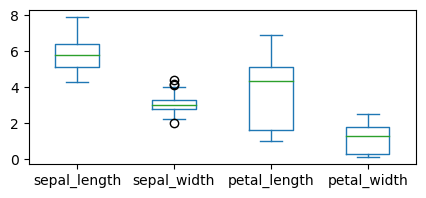

In [122]:
import matplotlib.pyplot as plt
X.plot(kind='box', figsize=(5,2))
plt.show()

In [123]:
X.rolling(5).mean().iloc[4:10] # 추세를 부드럽게 보고 싶을 때

,sepal_length,sepal_width,petal_length,petal_width
4,4.86,3.28,1.40,0.20
5,4.92,3.36,1.46,0.24
6,4.86,3.44,1.46,0.26
7,4.92,3.48,1.50,0.26
8,4.88,3.44,1.48,0.26
9,4.86,3.34,1.50,0.24


In [124]:
X.iloc[:10]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


## 8.2 요약통계량

### 1) 기본 요약 통계량
- 기본값 => 숫자컬럼에서의 요약 통계량
- 문자열에서의 요약 통계량 : 데이터 갯수, 종류(unique), 최빈값(top), 최빈값데이터갯수(freq)

In [125]:
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
43,5.0,3.5,1.6,0.6,setosa


In [126]:
# 숫자컬럼에서의 요약 통계량
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [127]:
# 문자열에서의 요약 통계량
iris['species'].describe()
iris.species.describe()

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

### 2) describe()의 include와 exclude 매개변수

In [232]:
df = pd.DataFrame({'a' : [1, 2, 3]*2,
                   'b' : [1.1, 2]*3,
                   'c' : ['aaa', 'bbb','aaa', 'ccc', 'aaa', 'bbb'],
                   'd' : [True, False]*3})
display(df)
df.info()

,a,b,c,d
0,1,1.1,aaa,True
1,2,2.0,bbb,False
2,3,1.1,aaa,True
3,1,2.0,ccc,False
4,2,1.1,aaa,True
5,3,2.0,bbb,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       6 non-null      int64  
 1   b       6 non-null      float64
 2   c       6 non-null      object 
 3   d       6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 278.0+ bytes


In [233]:
df.describe() # 숫자열만 기본 요약 통계량 return

,a,b
count,6.000000,6.00000
mean,2.000000,1.55000
std,0.894427,0.49295
min,1.000000,1.10000
25%,1.250000,1.10000
50%,2.000000,1.55000
75%,2.750000,2.00000
max,3.000000,2.00000


In [234]:
# include 매개변수를 통해서 요약통계량을 출력 타입 지정
df.describe(include=['int64', 'float64', 'bool'])

,a,b,d
count,6.000000,6.00000,6
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,3
mean,2.000000,1.55000,NaN
std,0.894427,0.49295,NaN
min,1.000000,1.10000,NaN
25%,1.250000,1.10000,NaN
50%,2.000000,1.55000,NaN
75%,2.750000,2.00000,NaN


In [132]:
# 문자형이나 bool의 요약 통계량
df.describe(include=['object', 'bool'])

,c,d
count,6,6
unique,3,2
top,aaa,True
freq,3,3


In [133]:
# exclude 매개 변수를 이용해서 제외할 타입 지정
df.describe(exclude='float64')

,a,c,d
count,6.000000,6,6
unique,NaN,3,2
top,NaN,aaa,True
freq,NaN,3,3
mean,2.000000,NaN,NaN
std,0.894427,NaN,NaN
min,1.000000,NaN,NaN
25%,1.250000,NaN,NaN
50%,2.000000,NaN,NaN
75%,2.750000,NaN,NaN


In [235]:
df.describe(include='all') # df의 모든 열의 요약 통계량 출력

,a,b,c,d
count,6.000000,6.00000,6,6
unique,NaN,NaN,3,2
top,NaN,NaN,aaa,True
freq,NaN,NaN,3,3
mean,2.000000,1.55000,NaN,NaN
std,0.894427,0.49295,NaN,NaN
min,1.000000,1.10000,NaN,NaN
25%,1.250000,1.10000,NaN,NaN
50%,2.000000,1.55000,NaN,NaN
75%,2.750000,2.00000,NaN,NaN


In [139]:
df['c'].unique() # 특정 컬럼의 고유 값들

array(['aaa', 'bbb', 'ccc'], dtype=object)

In [138]:
df['c'].value_counts() # 고유값들의 빈도(내림차순 정렬)

aaa    3
bbb    2
ccc    1
Name: c, dtype: int64

In [137]:
df.select_dtypes(include=['object']) # 해당 타입의 컬럼만 추출

,c
0,aaa
1,bbb
2,aaa
3,ccc
4,aaa
5,bbb


In [140]:
df.select_dtypes(exclude=object) # 해당 타입의 컬럼만 제외하고 추출

,a,b,d
0,1,1.1,True
1,2,2.0,False
2,3,1.1,True
3,1,2.0,False
4,2,1.1,True
5,3,2.0,False


## 8.3 공분산, 상관계수

- 공분산 : (x1-x1평균)*(x2-x2평균)들의 합을 n-1을 나눈 값
- 상관계수 :

In [141]:
X.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [142]:
# -1< 상관계수(공분산/x1의 표준편차*x2의 표준편차) <1
X.corr()
# X['sepal_length'].var()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


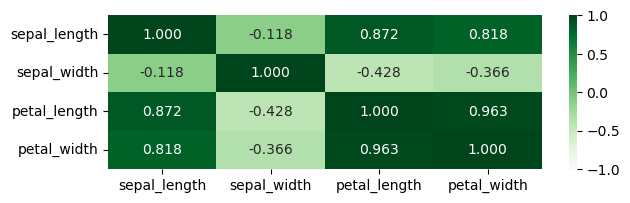

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,2)) # 그래프의 사이즈 조정
sns.heatmap(X.corr(), annot=True, vmin=-1, vmax=1, cmap='Greens', fmt='.3f')
plt.show()

# 9절. 데이터 그룹화 및 집계

## 9.1 Group by
    cf.pivot_table

In [150]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
25,5.0,3.0,1.6,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica
125,7.2,3.2,6.0,1.8,virginica


In [154]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


### 1) 그룹화 방법

-     df.groupby(by=[그룹핑할 열 이름])[함수적용해서 출력할 열들].기초통계함수()
                                     [함수 적용해서 출력할 열들] 생략시 모든 열이 적용
- df.groupby(by=[그룹할 열 이름들], as_index=T/F0[함수적용해서 출력할 열들].함수명())

In [155]:
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [157]:
# setosa, versicolor의 집계만
iris_grouped_sum.loc[['setosa', 'versicolor']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3


In [158]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [160]:
iris_grouped_sum.reset_index(inplace=True) # 인덱스를 컬럼으로 편입시킴

In [161]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [163]:
# setosa, virginica의 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


### 1-1) 그룹화 방법
 : 그룹핑할 때, index를 컬럼 데이터로 편입(reset_index()가 필요X)
- df.groupby(by=[그룹핑할 열 이름], as_index=False)[함수적용해서 출력할 열들].기초통계함수()
- [함수 적용해서 출력할 열들] 생략시 모든 열이 적용

In [165]:
iris.groupby(iris.Species, as_index=False).sum()
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [166]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length', 'Sepal.Width']]
iris.groupby('Species')[['Sepal.Length', 'Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [168]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 시리즈(1차원)
iris.groupby('Species')['Sepal.Length',].sum() # 튜플로 잡혀서 그러함(2차원)
iris.groupby('Species')[['Sepal.Length']].sum() # 결과가 데이터프레임(2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


### 2) 그룹화방법
df.pivot_table(index='그룹핑할 열이름들', \
        values=['함수적용해서 출력할 열들'], \
        aggfunc=함수명(기본값:mean)\
        )

In [170]:
iris.groupby('Species').mean()
g = iris.pivot_table(index='Species',
                # values= ,
                # aggfunc='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


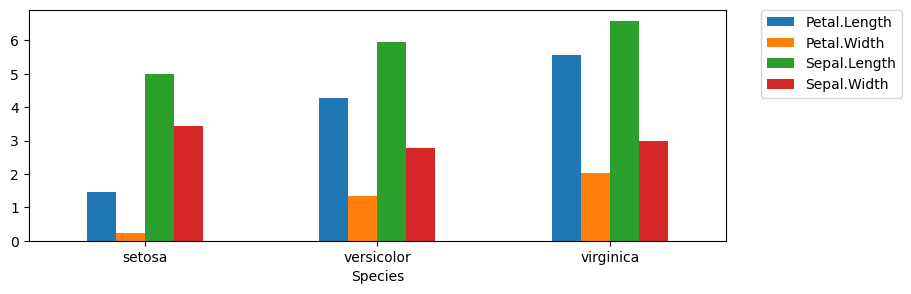

In [178]:
# 범례를 밖으로 : 시각화 20p. / 판다스60p.
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(9,3), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [180]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts() # 정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [183]:
# 임의로 각열마다 결측치를 할당
# (0번재 열은 결측치 1 / 1번째 열은 결측치2 / 2번째 열은 결츨치3 / 3번째 열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150), 3)
for col in range(iris.shape[1]-1):
    rows =  random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan

In [185]:
# 열별 결측치를 제외한 데이터 갯수
# iris.isna().sum()
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,50,49,50,50
versicolor,48,48,50,49
virginica,49,49,49,49


### 다중열로 그룹화

In [186]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [187]:
# iris로 다중열 그룹화하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species 3그룹, num 6그룹
iris['num'] = np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,NaN,virginica,5


In [188]:
# 종별, num별 합계
r = iris.groupby(['Species', 'num']).sum()
r

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species    num                                                      
setosa     0           125.7         87.0          36.5          6.0
           1           124.6         84.4          36.6          6.1
versicolor 2           150.3         69.4         103.3         32.1
           3           146.5         66.2         100.8         31.0
virginica  4           157.7         70.2         141.0         51.1
           5           165.0         75.5         131.1         48.4

In [190]:
r.loc[['setosa', 'virginica']] # setosa와 virginica의 합계만

Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
Species   num                                                      
setosa    0           125.7         87.0          36.5          6.0
          1           124.6         84.4          36.6          6.1
virginica 4           157.7         70.2         141.0         51.1
          5           165.0         75.5         131.1         48.4

In [191]:
r.loc[[('setosa', 0), ('virginica', 5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,36.5,6.0
virginica,5,165.0,75.5,131.1,48.4


In [192]:
# 종별, num별 합계
iris.pivot_table(index=['Species', 'num'])

Petal.Length  Petal.Width  Sepal.Length  Sepal.Width
Species    num                                                      
setosa     0        1.460000     0.250000      5.028000     3.480000
           1        1.464000     0.244000      4.984000     3.376000
versicolor 2        4.304167     1.337500      6.012000     2.776000
           3        4.200000     1.291667      5.860000     2.758333
virginica  4        5.640000     2.044000      6.570833     2.925000
           5        5.462500     2.016667      6.600000     3.020000

In [193]:
# 종별 기초 통계량들
iris.groupby(['Species']).describe().T

Species                setosa  versicolor  virginica
Sepal.Length count  50.000000   50.000000  49.000000
             mean    5.006000    5.936000   6.585714
             std     0.352490    0.516171   0.642262
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.200000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
Sepal.Width  count  50.000000   49.000000  49.000000
             mean    3.428000    2.767347   2.973469
             std     0.379064    0.316483   0.325817
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.500000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.200000
             max     4.400000    3.400000   3.800000
Petal.Length count  50.000000   48.000000  49.000000
             mean    1.462000    4.252083   5.553061
             std     0.173664    0.478023   0.557562
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.300000   5.600000
             75%     1.575000    4.600000   5.900000
             max     1.900000    5.100000   6.900000
Petal.Width  count  49.000000   48.000000  49.000000
             mean    0.246939    1.314583   2.030612
             std     0.106266    0.192398   0.275533
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000
num          count  50.000000   50.000000  50.000000
             mean    0.500000    2.500000   4.500000
             std     0.505076    0.505076   0.505076
             min     0.000000    2.000000   4.000000
             25%     0.000000    2.000000   4.000000
             50%     0.500000    2.500000   4.500000
             75%     1.000000    3.000000   5.000000
             max     1.000000    3.000000   5.000000

## 9.2 그룹간 데이터 처리

In [2]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [3]:
iris_grouped = iris.groupby('Species')
list(iris_grouped)

[('setosa',
      Sepal.Length  ...  Species
  0            5.1  ...   setosa
  1            4.9  ...   setosa
  2            4.7  ...   setosa
  3            4.6  ...   setosa
  4            5.0  ...   setosa
  5            5.4  ...   setosa
  6            4.6  ...   setosa
  7            5.0  ...   setosa
  8            4.4  ...   setosa
  9            4.9  ...   setosa
  10           5.4  ...   setosa
  11           4.8  ...   setosa
  12           4.8  ...   setosa
  13           4.3  ...   setosa
  14           5.8  ...   setosa
  15           5.7  ...   setosa
  16           5.4  ...   setosa
  17           5.1  ...   setosa
  18           5.7  ...   setosa
  19           5.1  ...   setosa
  20           5.4  ...   setosa
  21           5.1  ...   setosa
  22           4.6  ...   setosa
  23           5.1  ...   setosa
  24           4.8  ...   setosa
  25           5.0  ...   setosa
  26           5.0  ...   setosa
  27           5.2  ...   setosa
  28           5.2  ...   setos

In [7]:
# 종별 상위 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.head(3))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
101,5.8,2.7,5.1,1.9,virginica
102,7.1,3.0,5.9,2.1,virginica


In [10]:
# 종별 임의의 표본 3행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.sample(3).sort_index()) #.reset_index(drop=True))

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
14,5.8,4.0,1.2,0.2,setosa
28,5.2,3.4,1.4,0.2,setosa
38,4.4,3.0,1.3,0.2,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
55,5.7,2.8,4.5,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
120,6.9,3.2,5.7,2.3,virginica
139,6.9,3.1,5.4,2.1,virginica
142,5.8,2.7,5.1,1.9,virginica


In [11]:
# 종별 0, 15, 30, 45번째행 출력
for speciesname, group in iris_grouped:
    print(speciesname)
    display(group.iloc[[0,15,30,45]])    

setosa


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa
30,4.8,3.1,1.6,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa


versicolor


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
50,7.0,3.2,4.7,1.4,versicolor
65,6.7,3.1,4.4,1.4,versicolor
80,5.5,2.4,3.8,1.1,versicolor
95,5.7,3.0,4.2,1.2,versicolor


virginica


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
100,6.3,3.3,6.0,2.5,virginica
115,6.4,3.2,5.3,2.3,virginica
130,7.4,2.8,6.1,1.9,virginica
145,6.7,3.0,5.2,2.3,virginica


## 9.3 데이터프레임 그룹별 인덱싱

In [13]:
# # 종별 0, 15, 30, 45번째행 출력
# for speciesname, group in iris_grouped:
#     print(speciesname)
#     display(group.iloc[[0,15,30,45]])
r = iris.groupby('Species').take([0,15,30,45])
r

Sepal.Length  ...  Petal.Width
Species                       ...             
setosa     0             5.1  ...          0.2
           15            5.7  ...          0.4
           30            4.8  ...          0.2
           45            4.8  ...          0.3
versicolor 50            7.0  ...          1.4
           65            6.7  ...          1.4
           80            5.5  ...          1.1
           95            5.7  ...          1.2
virginica  100           6.3  ...          2.5
           115           6.4  ...          2.3
           130           7.4  ...          1.9
           145           6.7  ...          2.3

[12 rows x 4 columns]

In [16]:
r.loc['versicolor']

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
50,7.0,3.2,4.7,1.4
65,6.7,3.1,4.4,1.4
80,5.5,2.4,3.8,1.1
95,5.7,3.0,4.2,1.2


# 10절. 데이터 구조 변경
- 와이드포맷 <---> 롱포맷
- 판다스 공식문서에 나오는 melt : https://pandas.pydata.org/docs/user_guide/reshaping.html#melt-and-wide-to-long
- Tidy Data : https://vita.had.co.nz/papers/tidy-data.pdf


In [17]:
from statsmodels.api import  datasets
airquality = datasets.get_rdataset('airquality').data # 1973년 뉴욕 공기 질 데이터 셋
airquality

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


## 10.1 melt()를 이용한 언피벗팅(와이드포맷 → 롱포맷)
- df.met(id_vars, value_vars, var_name, value_name)
- pd.melt(df, id_vars, value_vars, vat_name, value_name)

In [20]:
# pd.melt(airquality, id_vars=['Month', 'Day'])
airquality_melted = airquality.melt(id_vars=['Month', 'Day'],
                                   # value_vars=['Ozone', 'Solar.R', 'Wind', 'Temp'] melt될 열이름
                                   )
airquality_melted

,Month,Day,variable,value
0,5,1,Ozone,41.0
1,5,2,Ozone,36.0
2,5,3,Ozone,12.0
3,5,4,Ozone,18.0
4,5,5,Ozone,NaN
...,...,...,...,...
148,9,26,Ozone,30.0
149,9,27,Ozone,NaN
150,9,28,Ozone,14.0
151,9,29,Ozone,18.0


In [22]:
airquality_melted = airquality.melt(id_vars=['Month', 'Day'],
                                   var_name='변수명', # melt된 데이터의 열이름
                                   value_name='값') # 데이터가 된 열이름
airquality_melted = airquality_melted.sort_values(by=['Month', 'Day']).reset_index(drop=True)
airquality_melted

,Month,Day,변수명,값
0,5,1,Ozone,41.0
1,5,1,Solar.R,190.0
2,5,1,Wind,7.4
3,5,1,Temp,67.0
4,5,2,Ozone,36.0
...,...,...,...,...
607,9,29,Temp,76.0
608,9,30,Ozone,20.0
609,9,30,Solar.R,223.0
610,9,30,Wind,11.5


## 10. 2 pivot_table을 이용한 피벗팅(롱포멧→와이드포맷)
- df.pivot_table(index, columns, values)
- pd.pivot_table(df, index, columns, values)

In [26]:
# pd.pivot_table(airquality_melted, index=['Month', 'Day'], columns='변수명', values='값')
airqulity2 = airquality_melted.pivot_table(index=['Month', 'Day'], columns='변수명',
                                           #values="값"
                                          )
airqulity2.columns = airqulity2.columns.droplevel(level=0)
airqulity2.columns.name = None
airqulity2 = airqulity2.reset_index()
airqulity2

,Month,Day,Ozone,Solar.R,Temp,Wind
0,5,1,41.0,190.0,67.0,7.4
1,5,2,36.0,118.0,72.0,8.0
2,5,3,12.0,149.0,74.0,12.6
3,5,4,18.0,313.0,62.0,11.5
4,5,5,NaN,NaN,56.0,14.3
...,...,...,...,...,...,...
148,9,26,30.0,193.0,70.0,6.9
149,9,27,NaN,145.0,77.0,13.2
150,9,28,14.0,191.0,75.0,14.3
151,9,29,18.0,131.0,76.0,8.0


# 11절. 데이터프레임에 함수 적용시키기
- apply(func, axis) : 데이터프레임이나 시리즈 모두 적용가능
- map(func) : 각 요소별로 func함수 적용(1차원 시리즈에서만 가능)
- applymap(func) : 각 요소별로 func 적용 (데이터프레임에서만 가능)

## 11.1 appy / map
### ex1. 1차원 시리즈에 apply / map 이용

In [28]:
import pandas as pd
member = pd.read_csv('Data/ch11_member.csv', comment='#')
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Age      5 non-null      int64 
 2   Email    5 non-null      object
 3   Address  5 non-null      object
 4   Birth    5 non-null      object
dtypes: int64(1), object(4)
memory usage: 328.0+ bytes


In [31]:
def get_year(datestr):
    return int(datestr.split('-')[0])
get_year = lambda datestr : int(datestr.split('-')[0])
get_year("1999-01-01")

1999

In [34]:
def get_month(x) :
    return int(x.split('-')[1])
get_month = lambda x : int(x.split('-')[1])
get_month("1999-01-01")

1

In [33]:
member['년'] = member['Birth'].map(lambda datestr : int(datestr.split('-')[0]))
member['월'] = member['Birth'].apply(lambda x : int(x.split('-')[1]))
member

,Name,Age,Email,Address,Birth,년,월
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1


### ex2. 2차원 데이터프레임에서 apply(func, axis)

In [35]:
%ls "C:/ai/Downloads/shareData/분양가격"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 1828-3575

 c:\ai\Downloads\shareData\분양가격 디렉터리

2026-07-14  오후 05:36    <DIR>          .
2026-07-14  오후 05:39    <DIR>          ..
2026-06-24  오후 10:04             2,163 전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv
2026-07-14  오후 05:35           501,367 주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv
               2개 파일             503,530 바이트
               2개 디렉터리  781,385,555,968 바이트 남음


In [36]:
df_last = pd.read_csv('C:/ai/Downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                     encoding='cp949')
df_last.head(2)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652


In [37]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [39]:
def year_month(series):
    return "{}-{:02}".format(series['연도'], series['월'])
#    return str(series['연도'])+"-"+(str(series['월']) if series['월']>=10 else ("0"+str(series['월'])))
year_month(df_last.loc[300])

'2016-01'

In [41]:
df_last['연도월'] = \
        df_last.apply(lambda series :  "{}-{:02}".format(series['연도'], series['월']), axis=1)
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),연도월
10875,제주,모든면적,2026,5,4473,2026-05
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,2026-05
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,2026-05
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,2026-05
10879,제주,전용면적 102제곱미터초과,2026,5,4350,2026-05


### ex3. 2차 데이터프레임에서 apply(func, axis=0)

In [42]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [45]:
import numpy as np
X = iris.iloc[:, :-1]
avg = np.mean(X, axis=0)
avg = X.mean(axis=0) # 열별평균
avg

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [47]:
# 각 열별 평균과의 거리를 출력
X.apply(lambda x: round(x-avg, 2), axis=1)

,sepal_length,sepal_width,petal_length,petal_width
0,-0.74,0.44,-2.36,-1.0
1,-0.94,-0.06,-2.36,-1.0
2,-1.14,0.14,-2.46,-1.0
3,-1.24,0.04,-2.26,-1.0
4,-0.84,0.54,-2.36,-1.0
...,...,...,...,...
145,0.86,-0.06,1.44,1.1
146,0.46,-0.56,1.24,0.7
147,0.66,-0.06,1.44,0.8
148,0.36,0.34,1.64,1.1


## 11. 2 applymap

In [48]:
X.applymap(lambda x : round(x, 3))

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


#### ※ malt() 및 함수 적용시키기 연습예제 (분양가격 csv 두파일 통합)
- 와이드포맷 → 롱포맷(melt) : 2013~2015년 데이터
- 평당분양가격/3.3 => 분양가격(제곱미터당 천원)
- 2013년 12월 -> 2013과 12를 나눠 '연도'와 '월' 컬럼 ( apply, map )
    => new_first
- df_last['규모구분'] == '모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원) 컬럼만)
- df_last의 지역명 컬럼명을 지역으로 변경
    => new_last
- pd.concat([new_first, new_last])

In [ ]:
df_last.

In [54]:
df_first = pd.read_csv('c:/ai/Downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv', 
                      encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [58]:
# 와이드포맷 → 롱포맷
new_first = df_first.melt(id_vars='지역', var_name='연도월', value_name = '평당분양가격')
new_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      357 non-null    object
 1   연도월     357 non-null    object
 2   평당분양가격  357 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.5+ KB


In [59]:
# 평당분양가격 / 3.3 → 제곱미터당분양가격
new_first['분양가격(제곱미터당 천원)'] = new_first['평당분양가격'] / 3.3
new_first.head()

,지역,연도월,평당분양가격,분양가격(제곱미터당 천원)
0,서울,2013년12월,18189,5511.818182
1,부산,2013년12월,8111,2457.878788
2,대구,2013년12월,8080,2448.484848
3,인천,2013년12월,10204,3092.121212
4,광주,2013년12월,6098,1847.878788


In [62]:
# 2013년 12월 → 2013과 12를 나눠 '연도'와 '월' 컬럼(apply, map)
def parse_year(datestr):
    return int(datestr.split(['년']))
(lambda datestr : int(datestr.split('년')[0]))("2013년12월")
def parse_month(datestr):
    return int(datestr.split('년')[1][:-1])
parse_month("2013년 12월")

12

In [64]:
new_first['연도'] = new_first['연도월'].map(lambda datestr : int(datestr.split('년')[0]))
new_first['월'] = new_first['연도월'].apply(lambda datestr : int(datestr.split('년')[1][:-1]))
new_first.drop(['연도월', '평당분양가격'], axis=1, inplace=True) # 불필요한 컬럼 drop(한번만 실행하기)
new_first.head(1)

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12


In [66]:
# df_last['규모구분'] == '모든면적' 데이터만 추출(지역명, 연도, 월, 분양가격(제곱미터당 천원) 컬럼만)
new_last = df_last.loc[df_last['규모구분']=='모든면적', ['지역명', '연도', '월', '분양가격(제곱미터당 천원)']]
# new_last.columns = ['지역', '연도', '월', '분양가격(제곱미터당 천원)']
new_last.rename(columns={'지역명' : '지역'}, inplace=True) # 지역명 컬럼명을 지역으로 변경
new_last.head(1)

,지역,연도,월,분양가격(제곱미터당 천원)
0,서울,2015,10,5841


In [69]:
# concat
df = pd.concat([new_first, new_last],
              # axis=0
              ).reset_index(drop=True) # 같은 컬럼명 기준으로 행 연결
df.loc[[0, 10, 20]]

,지역,분양가격(제곱미터당 천원),연도,월
0,서울,5511.818182,2013,12
10,충북,1996.666667,2013,12
20,인천,3092.121212,2014,1


# 12절. 일괄변경하기(결측치나 특정값)
## 12.1 fillna(결측치를 어떤 값으로 대체)
- 대부분의 결측치는 drop하거나 평균값, 중위수(중앙값, 2사분위수), 최빈값, 이전값, 다음값, 그룹별평균값으로 대채

In [71]:
df = pd.DataFrame([[np.nan, 2, np.nan, 0],
                 [3,       4, np.nan, 1],
                 [np.nan, 3, np.nan, 5],
                 [np.nan, 3, np.nan, 4]], columns=list('ABCD'))
df

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [72]:
# 모든 결측기를 무조건 0으로 대체
df.fillna(0)

,A,B,C,D
0,0.0,2,0.0,0
1,3.0,4,0.0,1
2,0.0,3,0.0,5
3,0.0,3,0.0,4


In [73]:
# 결측치를 이전행의 값으로 대체
df.fillna(method='ffill')

,A,B,C,D
0,NaN,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [74]:
# 결측치를 다음행의 값으로 대체
df.fillna(method='bfill')

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,NaN,3,NaN,5
3,NaN,3,NaN,4


In [75]:
# 결측치를 열마다 특정값으로 대체
values = {'A':99, 'B':98, 'C':97, 'D':96}
df.fillna(value=values)

,A,B,C,D
0,99.0,2,97.0,0
1,3.0,4,97.0,1
2,99.0,3,97.0,5
3,99.0,3,97.0,4


In [76]:
# 결측치를 각 열의 평균값(중위값, 최빈값)으로 대체
df.mean(axis=0) # 각열의 평균값
df.fillna(value=df.mean(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [78]:
# 결측치를 각 열의 평균값(중위값, 최빈값)으로 대체(결측치 대체는 2번째까지만)
df.fillna(value=df.mean(axis=0), limit=2)

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,NaN,3,NaN,4


In [77]:
# 결측치를 각 열의 중위수(중위값)으로 대체
df.fillna(value=df.median(axis=0))

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


In [80]:
# 결측치를 각 열의 최빈값으로 대체
df.fillna(df.mode().loc[0])

,A,B,C,D
0,3.0,2,NaN,0
1,3.0,4,NaN,1
2,3.0,3,NaN,5
3,3.0,3,NaN,4


##  12.2 replace(to_value, new_value, inplace=T/F)
- to_value를 new_value로 변경
- to_value에는 정규표현식 이용 가능
- 

In [83]:
s = pd.Series([0, 1, 2, 3, None])
s.replace(np.nan, 0, inplace=True)
s. replace([0, 1], 99) # 0이나 1을 99로 변경하라

0    99.0
1    99.0
2     2.0
3     3.0
4    99.0
dtype: float64

In [84]:
s = pd.Series([0, 1, 2, 3, None])
s.replace([0, 1, 2], [100, 101, 102])

0    100.0
1    101.0
2    102.0
3      3.0
4      NaN
dtype: float64

In [85]:
df = pd.DataFrame({'A': ['bat', 'foot', 'bait'],
                   'B': ['abc', 'bar', 'xyz']})
df

,A,B
0,bat,abc
1,foot,bar
2,bait,xyz


In [88]:
df.replace(r'ba.+', 'XX', regex=True)
df.replace('^ba.+$', 'XX', regex=True)
df.replace(regex='ba.+', value='XX')
df.replace(regex=['ba.+', 'fo.'], value='XX')

,A,B
0,XX,abc
1,XXt,XX
2,XX,xyz


In [91]:
df.replace({'A':'bat', 'B': 'abc'}, 'XX')

,A,B
0,XX,XX
1,foot,bar
2,bait,xyz


## 12.3 where(조건), mask(조건)


In [93]:
# 넘파이 where
a = np.array([1, 2, 3, 4, 5, 6])
np.where(a>3)

(array([3, 4, 5], dtype=int64),)

In [94]:
s = pd.Series(range(10, 20))
s

0    10
1    11
2    12
3    13
4    14
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [95]:
# 15이상 데이터추축
s[s>=15]

5    15
6    16
7    17
8    18
9    19
dtype: int64

In [97]:
s.where(s>=15) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않는 데이터는 결측치

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

In [98]:
s.where(s>=15, other=-1) # 조건이 만족되는 데이터는 그대로 출력. 만족되지 않는 데이터는 -1

0    -1
1    -1
2    -1
3    -1
4    -1
5    15
6    16
7    17
8    18
9    19
dtype: int64

In [99]:
s.where(s>=15) # 조건이 만족되는 데이터만 결측치

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5    15.0
6    16.0
7    17.0
8    18.0
9    19.0
dtype: float64

## 12. 4 dropna
- 결측치가 있는 데이터 누락)행기분,열 지군)


In [111]:
df = pd.DataFrame({'name':['홍', '김', np.nan, np.nan],
                 'age' :[np.nan, 20, 30, np.nan],
                 'bron' : ['서울', '부산', np.nan, np.nan]})
df

,name,age,bron
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


In [112]:
df.dropna(# axis=0
         ) # 결측치가 하나라도 있는 행을 drop. inplace=True가 아니면 return

,name,age,bron
1,김,20.0,부산


In [113]:
df.dropna(thresh=2) # 결측치가 아닌 값이 2개 이상이면 drop 안함

,name,age,bron
0,홍,NaN,서울
1,김,20.0,부산


In [114]:
df.dropna(subset=['name', 'age']) # name열과 age 열에 결측치가 하나라도 없는 행 drop

,name,age,bron
1,김,20.0,부산


In [115]:
df.dropna(how='all') # 모두 결측치인 행 drop

,name,age,bron
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN


In [117]:
df.dropna(axis=1) # 결측치가 하나라도 있는 열은 drop

""
0
1
2
3


In [116]:
df.dropna(axis=1, how='all') # 모두 결측치인 열은 drop

,name,age,bron
0,홍,NaN,서울
1,김,20.0,부산
2,NaN,30.0,NaN
3,NaN,NaN,NaN


### ※ iris 결측치를 열별 평균으로 대체( 교안 80p : fillna)

In [118]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [120]:
iris.isna().sum() #열마다 결측치 갯수
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [121]:
iris.notna().sum() #열마다 결측치를 제외한 데이터 갯수
iris.notnull().sum()

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
species         150
dtype: int64

In [122]:
# 1단계 :iris 데이터에서 결측치를 인위적으로 random하게 열 마다 20씩 결측치를 할당한다.
import random
print(random.sample(range(iris.shape[0]),20))

[91, 4, 122, 18, 44, 37, 84, 108, 66, 55, 98, 72, 96, 76, 80, 33, 127, 40, 86, 131]


In [125]:
for col in range(iris.shape[1]-1):
    randomidx = random.sample(range(iris.shape[0]), 20)
#     print(col, randomidx)
    iris.iloc[randomidx, col] = np.nan
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [126]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,NaN,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [128]:
# 2단계 : 결측치가 있는 iris데이터를 출력한다
iris[iris['sepal_length'].isna() | iris['sepal_width'].isna() |
     iris['petal_length'].isnull() | iris['petal_width'].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,NaN,1.4,0.2,setosa
5,5.4,NaN,1.7,NaN,setosa
7,5.0,NaN,1.5,0.2,setosa
8,4.4,NaN,1.4,0.2,setosa
12,4.8,NaN,NaN,0.1,setosa
...,...,...,...,...,...
136,NaN,3.4,5.6,NaN,virginica
137,6.4,3.1,5.5,NaN,virginica
142,NaN,2.7,NaN,NaN,virginica
143,6.8,3.2,5.9,NaN,virginica


In [143]:
# 3단계 : 결측치를 열평균으로 대체된 iris데이터를 출력
iris.iloc[:, :-1].mean(axis=0) # 열평균
iris.mean(axis=0, numeric_only=True) #열평균
iris_fillna = iris.fillna(value=iris.iloc[:, :-1].mean(axis=0))
iris_fillna.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [142]:
# 소수점 3자리에서 반올림
iris_fillna.iloc[:, :-1] = iris_fillna.iloc[:, :-1].applymap(lambda x : np.round(x, 3))
iris_fillna

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.500,1.400,0.2,setosa
1,4.9,3.036,1.400,0.2,setosa
2,4.7,3.200,1.300,0.2,setosa
3,4.6,3.100,1.500,0.2,setosa
4,5.0,3.600,1.400,0.2,setosa
...,...,...,...,...,...
145,6.7,3.000,5.200,2.3,virginica
146,6.3,2.500,5.000,1.9,virginica
147,6.5,3.000,5.200,2.0,virginica
148,6.2,3.400,5.400,2.3,virginica


### ※ iris 결측치를 종별, 열별 평균으로 대체(apply 적용)

In [144]:
# 결측치를 종별, 열평균으로 대체된 iris데이터를 출력
iris.isna().sum()

sepal_length    20
sepal_width     20
petal_length    20
petal_width     20
species          0
dtype: int64

In [145]:
iris_mean = iris.groupby(by=['species']).mean()
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.000000,3.415000,1.455814,0.243182
versicolor,5.911628,2.773333,4.202326,1.337778
virginica,6.614634,2.962222,5.561364,2.031707


In [146]:
iris.fillna(value=iris_mean) # 결측치 대체값이 iris_mean이면 대체가 안됨

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,NaN,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [147]:
iris_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.000000,3.415000,1.455814,0.243182
versicolor,5.911628,2.773333,4.202326,1.337778
virginica,6.614634,2.962222,5.561364,2.031707


In [151]:
iris_mean.loc['setosa', 'sepal_width']

3.415

In [157]:
# np.isnan(스칼라값) : nan만 결측치로 인식하고 결측치인지 여부(값이 숫자형이어야 함)
# pd.isna(스칼라값), pd.isnull(스칼라값) : nan과 None을 모두 결측치로 인식하고 결측치인지 여부(값이 숫자형이 아니어도 됨)

def fillna_grouped_mean(row):
    row = row.copy()
    for col, item in row.items():
        # print(col, item , row[col])
        # item이 결측치이면 해당 species를 가져와서 대체할 결측치 iris_mean.loc[종이름, col]로 대체
        # if col!='species' and np.isnan(item): # 결측치인지 여부 확인
        if pd.isna(item):
            species = row['species']
            row[col] = iris_mean.loc[species, col] # 종별 열별 평균값으로 대체
    return row

fillna_grouped_mean(iris.iloc[1])

sepal_length       4.9
sepal_width      3.415
petal_length       1.4
petal_width        0.2
species         setosa
Name: 1, dtype: object

In [158]:
iris.apply(fillna_grouped_mean, axis=1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.500,1.400000,0.2,setosa
1,4.9,3.415,1.400000,0.2,setosa
2,4.7,3.200,1.300000,0.2,setosa
3,4.6,3.100,1.500000,0.2,setosa
4,5.0,3.600,1.400000,0.2,setosa
...,...,...,...,...,...
145,6.7,3.000,5.200000,2.3,virginica
146,6.3,2.500,5.000000,1.9,virginica
147,6.5,3.000,5.200000,2.0,virginica
148,6.2,3.400,5.400000,2.3,virginica


# 13절. 시리즈
- 1차원 데이터

In [159]:
s = pd.Series([1000, 7000, 5000], index=['banana', 'mango', 'apple'])
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [161]:
s['banana'], s.banana

(1000, 1000)

In [162]:
s['banana':'apple']

banana    1000
mango     7000
apple     5000
dtype: int64

In [163]:
# 데이터 추가
s['watermelon'] = 20000
s

banana         1000
mango          7000
apple          5000
watermelon    20000
dtype: int64

In [165]:
# 데이터 drop
s.drop('watermelon', inplace=True)
s

banana    1000
mango     7000
apple     5000
dtype: int64

In [167]:
s = s.sort_index()
s

apple     5000
banana    1000
mango     7000
dtype: int64

In [168]:
# 값에 의한 정렬(기본은 ascending+True 오름차순)
s.sort_values()

banana    1000
apple     5000
mango     7000
dtype: int64

In [169]:
# 내림차순
s.sort_values(ascending=False)

mango     7000
apple     5000
banana    1000
dtype: int64

In [171]:
# 열이름을 지정하여 데이터프레임으로 전환
s.to_frame(name='price')

,price
apple,5000
banana,1000
mango,7000


In [173]:
s.to_frame(name='price').T

,apple,banana,mango
price,5000,1000,7000


# 연습문제
## 실습형
```
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)
```
### 1. iris 데이터에서 처음 다섯개 행만 출력하세요.

In [185]:
import seaborn as sns
iris = sns.load_dataset("iris")
type(iris)

pandas.core.frame.DataFrame

In [281]:
iris.iloc[:5]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. iris 데이터를 데이터프레임 변수인 독립변수 x와 종속변수 y로 나누세요. 
       종속변수는 species열입니다.

In [282]:
x = iris.iloc[:, :-1]
y = iris.iloc[:, -1:]

### 3. iris 데이터에서 처음 50개행을 빼내서 temp변수에 저장하세요.

In [215]:
temp = iris.iloc[:50]

### 4. 3번에서 선택한 데이터프레임의 요약정보를 출력하세요. 
모든 열에 대한 요약정보가 출력되어야 합니다.

In [283]:
temp.describe(include='all')

,sepal_length,sepal_width,petal_length,petal_width,species
count,50.00000,50.000000,50.000000,50.000000,50
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.00600,3.428000,1.462000,0.246000,NaN
std,0.35249,0.379064,0.173664,0.105386,NaN
min,4.30000,2.300000,1.000000,0.100000,NaN
25%,4.80000,3.200000,1.400000,0.200000,NaN
50%,5.00000,3.400000,1.500000,0.200000,NaN
75%,5.20000,3.675000,1.575000,0.300000,NaN


### 5. versicolor종의 데이터만 iris_versicolor변수에 저장하세요

In [238]:
iris_versicolor = iris[iris['species'].str.startswith('versicolor')]
iris_versicolor

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
55,5.7,2.8,4.5,1.3,versicolor
56,6.3,3.3,4.7,1.6,versicolor
57,4.9,2.4,3.3,1.0,versicolor
58,6.6,2.9,4.6,1.3,versicolor
59,5.2,2.7,3.9,1.4,versicolor


### 6. 2번의 x와 y변수를 합해서 iris_df 데이터프레임으로 만들세요.

In [244]:
iris_df = pd.concat([x, y], axis=1)
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


###  7. iris 데이터의 각 열 평균값을 출력하세요.

In [284]:
ex7 = iris_df.mean(axis=0, numeric_only=True)
ex7

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

### 8. iris 데이터의 각 열들 사이의 상관계수를 출력하세요.

In [250]:
iris.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


### 9. iris 데이터에서 각 요소들과 변수별 평균과의 차이를 출력하세요.
다음 그림은 처음 다섯 개 행의 출력 결과입니다.

In [285]:
ex9 = iris_df - ex7
ex9.iloc[:5, :4]

,petal_length,petal_width,sepal_length,sepal_width
0,-2.358,-0.999333,-0.743333,0.442667
1,-2.358,-0.999333,-0.943333,-0.057333
2,-2.458,-0.999333,-1.143333,0.142667
3,-2.258,-0.999333,-1.243333,0.042667
4,-2.358,-0.999333,-0.843333,0.542667


In [288]:
# iris.iloc[:, :-1].apply(lambda x : x-iris_mean, axis=1)

### 10. iris 데이터의 종별 평균을 출력하세요.

In [280]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### 11. iris 데이터에서 각 요소들과 종별 변수의 평균과의 차이를 출력하세요. 
각 종별로 3개씩 출력하세요. 다음 그림은 출력 예입니다.

In [289]:
# 종별 열별평균의 차이를 출력
mean_by_species = iris.groupby('species').mean()
mean_by_species.loc['setosa']

sepal_length    5.006
sepal_width     3.428
petal_length    1.462
petal_width     0.246
Name: setosa, dtype: float64

In [291]:
result = iris.apply(lambda row : row - mean_by_species.loc[row.species], axis=1)
result.groupby(iris.species).head(3)

,petal_length,petal_width,sepal_length,sepal_width,species
0,-0.062,-0.046,0.094,0.072,NaN
1,-0.062,-0.046,-0.106,-0.428,NaN
2,-0.162,-0.046,-0.306,-0.228,NaN
50,0.440,0.074,1.064,0.430,NaN
51,0.240,0.174,0.464,0.430,NaN
52,0.640,0.174,0.964,0.330,NaN
100,0.448,0.474,-0.288,0.326,NaN
101,-0.452,-0.126,-0.788,-0.274,NaN
102,0.348,0.074,0.512,0.026,NaN


In [292]:
result1 = result.groupby(iris.species).take([0, 1, 2])
result1.index.droplevel(level=0)

petal_length  ...  species
species                       ...         
setosa     0          -0.062  ...      NaN
           1          -0.062  ...      NaN
           2          -0.162  ...      NaN
versicolor 50          0.440  ...      NaN
           51          0.240  ...      NaN
           52          0.640  ...      NaN
virginica  100         0.448  ...      NaN
           101        -0.452  ...      NaN
           102         0.348  ...      NaN

[9 rows x 5 columns]